# Decision Trees su „Titanic“ duomenimis

Šiame faile parodomas sprendimų medžio klasifikatoriaus taikymas, naudojant „Titanic“ duomenų rinkinį:
- sprendimų medžiai (principas)
- EDA
- modelio parinkimas ir metrikos
- sprendimų medžio apmokymas
- medžio vizualizacija
- feature importance ir vizualizacijos
- hiperparametrų parinkimas (tuning) ir overfitting mažinimas

Pastaba: sprendimų medžiai neturi regresijos tipo koeficientų. Vietoje jų interpretacijai naudojami **skaidymo taisyklės** (if–then) ir **feature importance**.


## 1. Bibliotekos ir duomenys

„Titanic“ duomenys įkeliami iš `seaborn` bibliotekos. Tai patogu demonstracijai, nes nereikia atskiro CSV failo.


In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, RocCurveDisplay
)

# Duomenų įkėlimas
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [2]:
df.dtypes

survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
sibsp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


## 2. EDA (Exploratory Data Analysis)

Pagrindiniai tikslai:
- suprasti stulpelių tipus ir trūkstamas reikšmes
- pasižiūrėti target pasiskirstymą (`survived`)
- patikrinti kelias aiškias sąsajas (pvz., `sex`, `pclass`, `age`, `fare`)

Dažna klaida: pradėti modeliavimą neįvertinus trūkstamų reikšmių ir kategorinių kintamųjų apdorojimo.


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [5]:
df["survived"].value_counts(dropna=False)

survived
0    549
1    342
Name: count, dtype: int64

In [6]:
df[["survived"]].value_counts(normalize=True)

survived
0           0.616162
1           0.383838
Name: proportion, dtype: float64

### Trūkstamos reikšmės

Sprendimų medžiai `sklearn` bibliotekoje negali priimti `NaN` reikšmių, todėl būtinas imputavimas.


In [7]:
df.isna().mean().sort_values(ascending=False).head(12)

deck           0.772166
age            0.198653
embarked       0.002245
embark_town    0.002245
survived       0.000000
pclass         0.000000
sex            0.000000
sibsp          0.000000
parch          0.000000
fare           0.000000
class          0.000000
who            0.000000
dtype: float64

### Greitos vizualizacijos

Vizualizacijos tikslas – greitai pamatyti, kurios savybės turi akivaizdų ryšį su `survived`.


In [8]:
# Target pagal lytį
tmp = df.groupby("sex")["survived"].mean().sort_values(ascending=False)
tmp

sex
female    0.742038
male      0.188908
Name: survived, dtype: float64

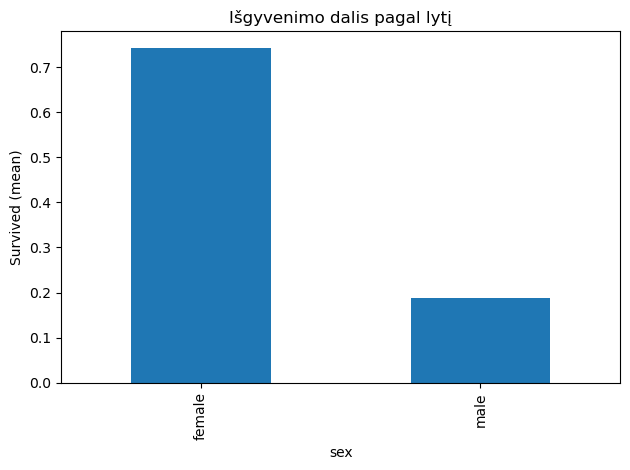

In [9]:
tmp.plot(kind="bar")
plt.title("Išgyvenimo dalis pagal lytį")
plt.ylabel("Survived (mean)")
plt.xlabel("sex")
plt.tight_layout()
plt.show()

In [10]:
# Target pagal klasę (pclass)
tmp = df.groupby("pclass")["survived"].mean().sort_values(ascending=False)
tmp

pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64

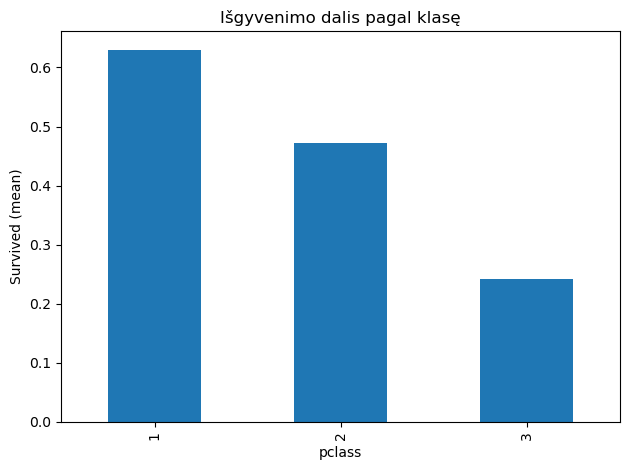

In [11]:
tmp.plot(kind="bar")
plt.title("Išgyvenimo dalis pagal klasę")
plt.ylabel("Survived (mean)")
plt.xlabel("pclass")
plt.tight_layout()
plt.show()

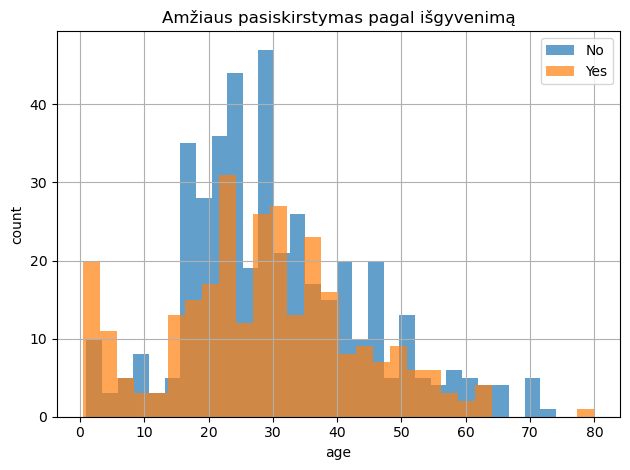

In [12]:
# Amžiaus pasiskirstymas, atskirai pagal target
df_plot = df[["age", "survived"]].dropna()
df_plot[df_plot["survived"] == 0]["age"].hist(bins=30, alpha=0.7)
df_plot[df_plot["survived"] == 1]["age"].hist(bins=30, alpha=0.7)
plt.title("Amžiaus pasiskirstymas pagal išgyvenimą")
plt.xlabel("age")
plt.ylabel("count")
plt.legend(["No", "Yes"])
plt.tight_layout()
plt.show()

## 3. Model selection ir metrikos

Klasifikacijai dažniausiai naudojamos metrikos:
- **accuracy**: teisingų spėjimų dalis
- **precision**: kiek iš prognozuotų „Yes“ buvo teisingi
- **recall**: kiek iš realių „Yes“ buvo aptikta
- **F1**: balansas tarp precision ir recall
- **ROC AUC**: modelio gebėjimas atskirti klases pagal tikimybes

Dažna klaida: remtis tik accuracy, ypač kai klasės nesubalansuotos. „Titanic“ klasės nėra ekstremaliai nesubalansuotos, bet papildomos metrikos vis tiek naudingos.


### Duomenų paruošimas

Pasirenkami keli aiškūs kintamieji, kad medis būtų interpretuojamas.  
Naudojamas `Pipeline` ir `ColumnTransformer`, kad:
- skaitiniai kintamieji būtų imputuojami medianomis
- kategoriniai būtų imputuojami dažniausia reikšme ir `OneHotEncoded`


Pipeline yra įrankis, leidžiantis sujungti kelis duomenų apdorojimo ir modelio kūrimo žingsnius į vieną procesą.

Pipeline veikia kaip seka, kur kiekvienas žingsnis automatiškai perduoda rezultatą kitam žingsniui. Dažniausiai pipeline sudaro:
duomenų transformacija (pvz., skalavimas ar kategorinių kintamųjų kodavimas) ir pats modelis.

Pavyzdžiui, pipeline gali atlikti šiuos veiksmus:
1) standartizuoti duomenis,
2) pritaikyti klasifikavimo modelį.

Pagrindiniai pipeline privalumai:
– visi modelio kūrimo žingsniai atliekami nuosekliai ir automatiškai  
– sumažėja klaidų rizika duomenų paruošime  
– lengviau taikyti cross-validation ir hiperparametrų tuning  
– visas procesas tampa lengviau pakartojamas ir pritaikomas naujiems duomenims.

Todėl pipeline dažnai naudojamas kaip standartinė praktika kuriant machine learning modelius.

In [13]:
# Parenkami kintamieji (minimaliai, bet prasmingai)
features = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]
target = "survived"

data = df[features + [target]].copy()

X = data[features]
y = data[target]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

numeric_features = ["age", "sibsp", "parch", "fare"]
categorical_features = ["pclass", "sex", "embarked"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

preprocess

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['age', 'sibsp', 'parch', 'fare']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['pclass', 'sex', 'embarked'])])

### Baseline (naivi) prognozė

Naivi baseline prognozė: visiems priskirti dažniausią klasę. Tai paprastas atskaitos taškas.


In [14]:
# Baseline: visiems prognozuojama dažniausia klasė train rinkinyje
majority_class = int(y_train.value_counts().idxmax())
y_pred_base = np.full_like(y_test, fill_value=majority_class)

acc_base = accuracy_score(y_test, y_pred_base)
acc_base

0.6143497757847534

## 4. Sprendimų medžio apmokymas (fitting)

Pradinis modelis be hiperparametrų apribojimų dažnai per daug prisitaiko prie train duomenų (overfitting).


In [15]:
dt_default = Pipeline(steps=[
    ("prep", preprocess),
    ("model", DecisionTreeClassifier(random_state=42))
])

dt_default.fit(X_train, y_train)

y_pred_train = dt_default.predict(X_train)
y_pred_test = dt_default.predict(X_test)

train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)

train_acc, test_acc

(0.9775449101796407, 0.7219730941704036)

### Metrikų suvestinė

Žemiau pateikiamos kelios metrikos, kad būtų aišku, ar modelis subalansuotai veikia abiem klasėms.


In [16]:
def metrics_report(y_true, y_pred, y_proba=None):
    out = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }
    if y_proba is not None:
        out["roc_auc"] = roc_auc_score(y_true, y_proba)
    return pd.Series(out)

# Tikimybės ROC AUC skaičiavimui
proba_test_default = dt_default.predict_proba(X_test)[:, 1]

pd.DataFrame({
    "train": metrics_report(y_train, dt_default.predict(X_train), dt_default.predict_proba(X_train)[:, 1]),
    "test": metrics_report(y_test, y_pred_test, proba_test_default),
})

,train,test
accuracy,0.977545,0.721973
precision,0.995885,0.633333
recall,0.945312,0.662791
f1,0.969940,0.647727
roc_auc,0.998824,0.705865


Modelio rezultatai rodo ryškų skirtumą tarp treniravimo ir testavimo duomenų.

Treniravimo rinkinyje visi rodikliai yra labai aukšti (accuracy ≈ 0.98, ROC AUC ≈ 0.999), todėl modelis beveik tobulai atskiria klases. 

Testavimo rinkinyje rodikliai reikšmingai sumažėja (accuracy ≈ 0.72, ROC AUC ≈ 0.71). Precision ir recall taip pat vidutiniai (~0.63–0.66), o F1 ≈ 0.65 rodo tik vidutinį balansą tarp jautrumo ir tikslumo.

Toks skirtumas tarp train ir test rezultatų rodo galimą modelio per didelį prisitaikymą prie treniravimo duomenų (overfitting). Modelis labai gerai išmoksta treniravimo pavyzdžius, tačiau prasčiau generalizuoja naujiems duomenims.


In [17]:
print(classification_report(y_test, y_pred_test, target_names=["No", "Yes"], zero_division=0))

              precision    recall  f1-score   support

          No       0.78      0.76      0.77       137
         Yes       0.63      0.66      0.65        86

    accuracy                           0.72       223
   macro avg       0.71      0.71      0.71       223
weighted avg       0.72      0.72      0.72       223



Bendras modelio tikslumas (accuracy) yra 0.72, todėl apie 72 % keleivių buvo klasifikuoti teisingai.

„No“ klasėje (neišgyveno) precision = 0.78 ir recall = 0.76. Tai reiškia, kad modelis gana stabiliai atpažįsta neišgyvenusius keleivius ir daugumos jų nepraleidžia.

„Yes“ klasėje (išgyveno) precision = 0.63, recall = 0.66. Tai rodo, kad modelis prasčiau identifikuoja išgyvenusius keleivius – dalis jų klasifikuojama klaidingai kaip „No“.

F1-score abiem klasėms yra vidutinis (0.77 ir 0.65), o macro average ≈ 0.71 rodo panašų bendrą veikimą abiejų klasių atžvilgiu.

Išvada: modelis veikia vidutiniškai, šiek tiek geriau prognozuoja neišgyvenusius nei išgyvenusius keleivius.


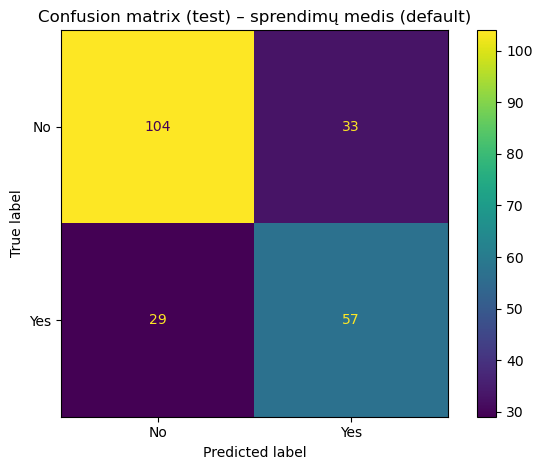

In [18]:
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
disp.plot()
plt.title("Confusion matrix (test) – sprendimų medis (default)")
plt.tight_layout()
plt.show()

Teisingos prognozės:
104 (No teisingai) + 57 (Yes teisingai) = 161

Accuracy (bendras taiklumas):
161 / 223 = 0.722 ≈ 72.2 %

No klasė (neišgyveno):
Iš 137 tikrų „No“ atvejų modelis teisingai atpažino 104.
104 / 137 = 0.759 ≈ 75.9 %

Yes klasė (išgyveno):
Iš 86 tikrų „Yes“ atvejų modelis teisingai atpažino 57.
57 / 86 = 0.663 ≈ 66.3 %

Išvada:
Modelis bendrąja prasme teisingai klasifikuoja apie 72 % keleivių.
Jis geriau atpažįsta neišgyvenusius (apie 76 %) nei išgyvenusius (apie 66 %).


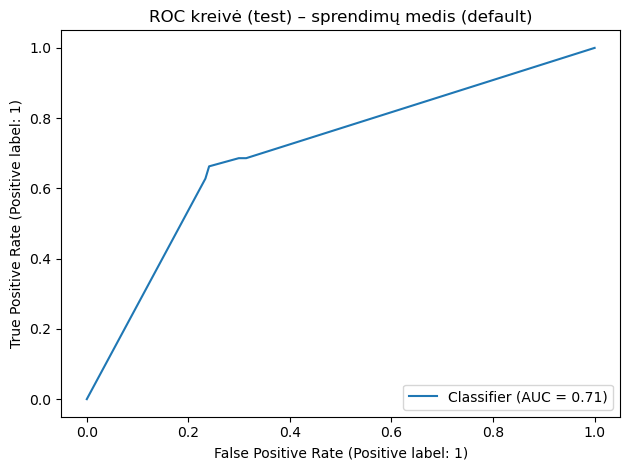

In [19]:
RocCurveDisplay.from_predictions(y_test, proba_test_default)
plt.title("ROC kreivė (test) – sprendimų medis (default)")
plt.tight_layout()
plt.show()

ROC kreivė parodo modelio gebėjimą atskirti klases esant skirtingiems sprendimo slenksčiams.

Grafike vaizduojama:
- X ašis – False Positive Rate (klaidingai teigiamų dalis),
- Y ašis – True Positive Rate (teisingai teigiamų dalis).

Modelio AUC (Area Under the Curve) = 0.71.

Tai reiškia, kad modelis turi apie 71 % tikimybę teisingai atskirti atsitiktinį „Yes“ atvejį nuo atsitiktinio „No“ atvejo. 

Kadangi AUC = 0.5 reikštų atsitiktinį spėjimą, o 1.0 – tobulą klasifikatorių, 0.71 rodo vidutinį, bet ne stiprų diskriminacinį gebėjimą.

Išvada: modelis geba atskirti klases geriau nei atsitiktinai, tačiau jo prognozavimo kokybė yra vidutinė.


## 5. Sprendimų medžio vizualizacija

`plot_tree` veikia su pačiu `DecisionTreeClassifier` objektu, todėl reikia ištraukti apmokytą modelį iš `Pipeline`.  
Kad vizualizacija būtų suprantama, medžio gylis ribojamas (pvz., iki 3–4). Giliai išaugintas medis tampa praktiškai nebeįskaitomas.


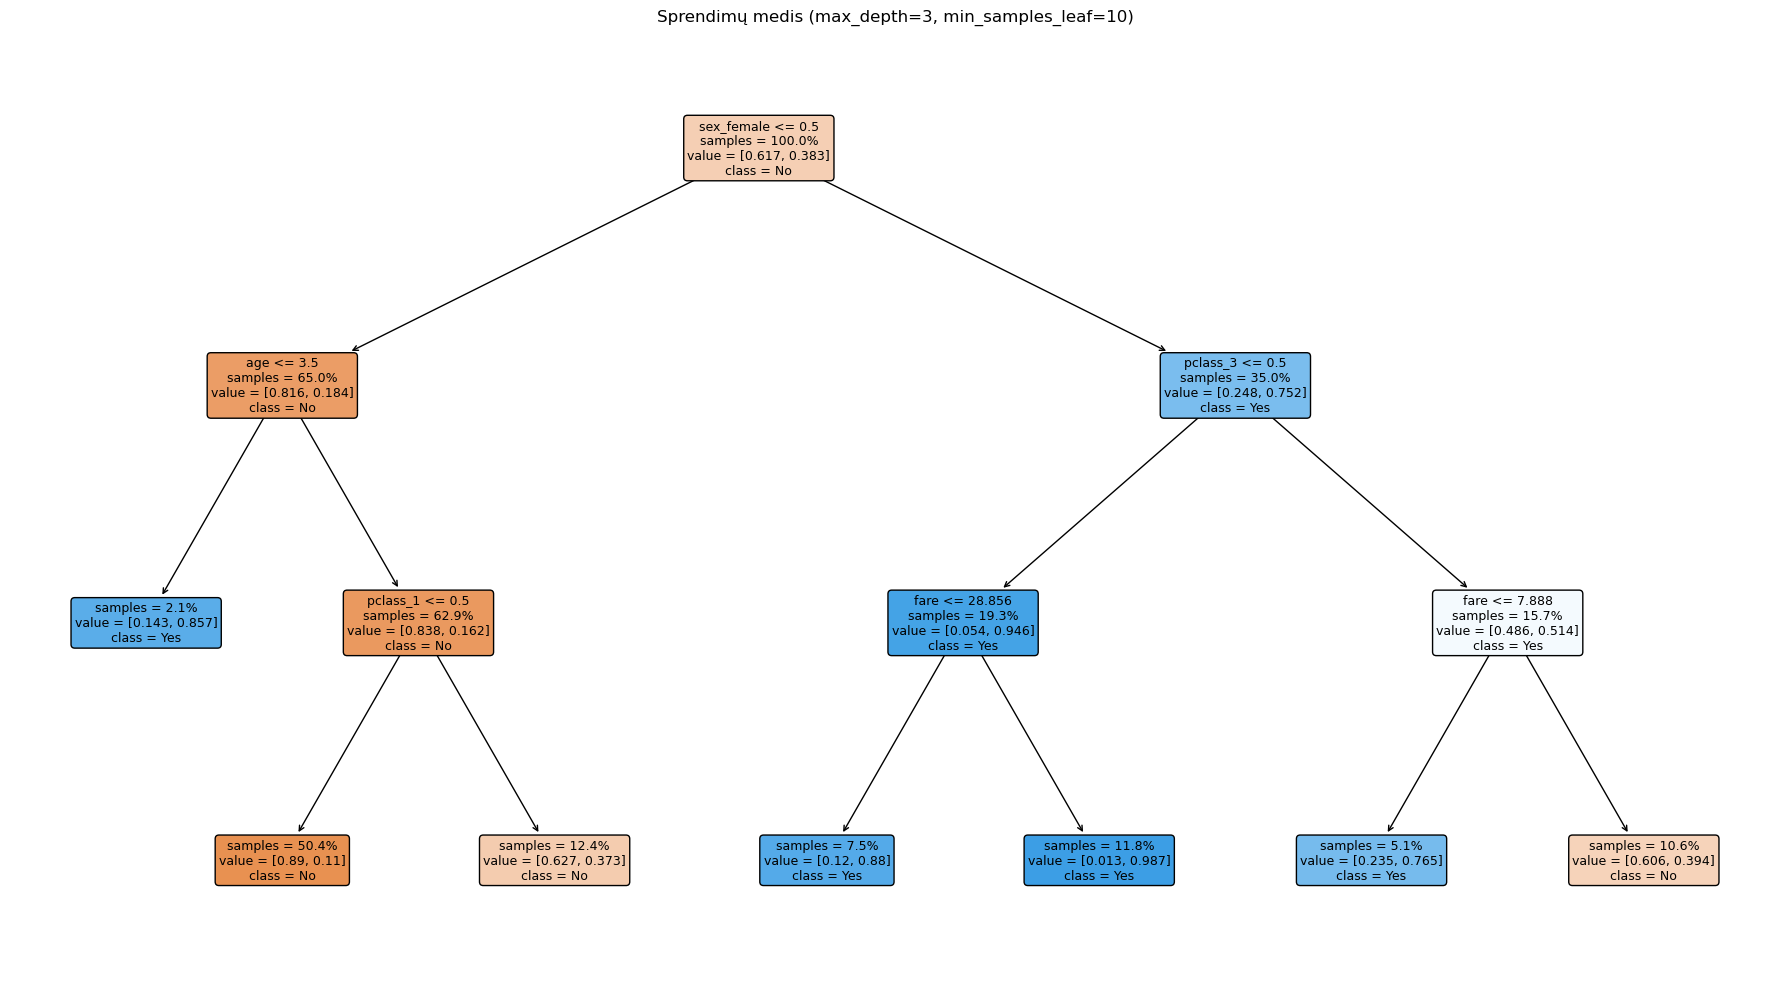

In [20]:
dt_small = Pipeline(steps=[
    ("prep", preprocess),
    ("model", DecisionTreeClassifier(max_depth=3, min_samples_leaf=10, random_state=42))
])

dt_small.fit(X_train, y_train)

# Ištraukiamas paruoštas modelis ir stulpelių pavadinimai po OneHot
model_small = dt_small.named_steps["model"]
ohe = dt_small.named_steps["prep"].named_transformers_["cat"].named_steps["onehot"]
cat_names = ohe.get_feature_names_out(categorical_features)

feature_names = numeric_features + list(cat_names)

plt.figure(figsize=(18, 10))
plot_tree(
    model_small,
    feature_names=feature_names,
    class_names=["No", "Yes"],
    proportion=True,
    filled=True,
    impurity=False,
    rounded=True,
    fontsize=9
)
plt.title("Sprendimų medis (max_depth=3, min_samples_leaf=10)")
plt.tight_layout()
plt.show()

Sprendimų medis yra apribotas (max_depth=3, min_samples_leaf=10), todėl yra paprastesnis ir mažiau linkęs į per didelį prisitaikymą.

Pirmasis ir svarbiausias skyrimas vyksta pagal lytį (sex_female). Tai rodo, kad lytis yra stipriausias veiksnys prognozuojant išgyvenimą.

Kairėje pusėje (dažniausiai vyrai) dominuoja „No“ klasė – dauguma jų neišgyveno. Tolimesni skyrimai pagal amžių ir keleivio klasę (pclass) tik patikslina šią tendenciją.

Dešinėje pusėje (dažniausiai moterys) dominuoja „Yes“ klasė – dauguma jų išgyveno. Papildomi skyrimai pagal bilieto kainą (fare) ir klasę padeda atskirti rizikingesnes grupes.

Vertės „samples“ rodo, kokia procentinė duomenų dalis patenka į konkretų mazgą, o „value“ pateikia klasių proporcijas tame mazge. Kai viena proporcija yra labai didelė (pvz., 0.987), prognozė tampa beveik užtikrinta.

Išvada: modelis aiškiai parodo, kad lytis yra pagrindinis veiksnys, o keleivio klasė ir bilieto kaina papildomai diferencijuoja išgyvenimo tikimybę.


## 6. Feature importance ir vizualizacija

Feature importance parodo, kurie kintamieji labiausiai prisidėjo prie sprendimų (entropijos / gini mažinimo).  
Tai nėra priežastinis ryšys – tai prognozinis indėlis šiame konkrečiame modelyje.

Dažnos klaidos:
- interpretuoti „0 svarbą“ kaip „visiškai nereikšminga verslui“ (tai tik reiškia, kad medis jos nepanaudojo)
- ignoruoti, kad stiprus prediktorius gali „užgožti“ kitus kintamuosius


In [21]:
importances = pd.Series(model_small.feature_importances_, index=feature_names).sort_values(ascending=False)
importances.head(15)

sex_female    0.658131
pclass_3      0.144681
age           0.087930
pclass_1      0.062183
fare          0.047076
sibsp         0.000000
parch         0.000000
pclass_2      0.000000
sex_male      0.000000
embarked_C    0.000000
embarked_Q    0.000000
embarked_S    0.000000
dtype: float64

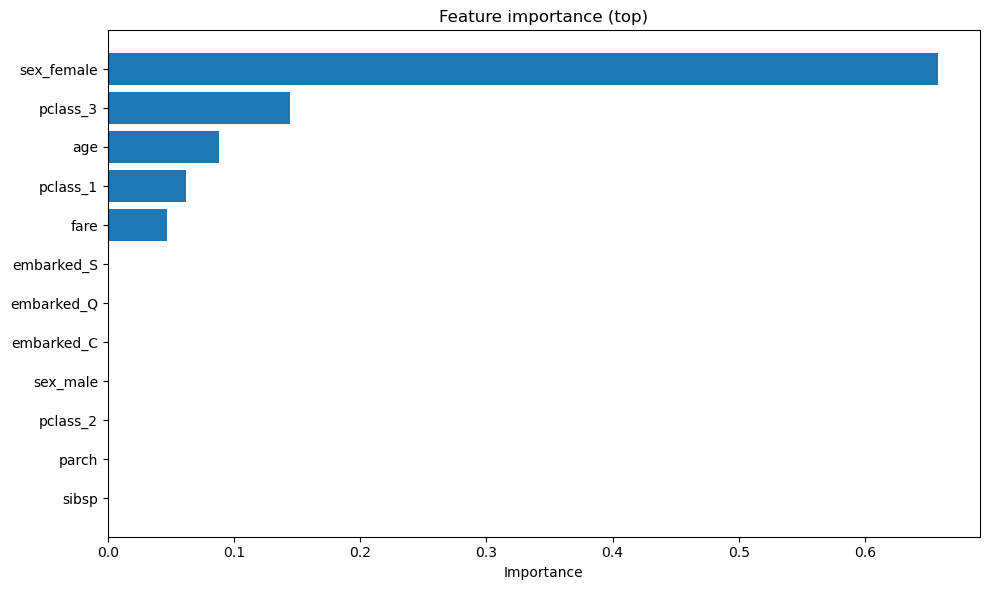

In [22]:
top_k = 12
imp_top = importances.head(top_k).sort_values()

plt.figure(figsize=(10, 6))
plt.barh(imp_top.index, imp_top.values)
plt.title("Feature importance (top)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 7. Hiperparametrų parinkimas (tuning)

Tikslas – sumažinti overfitting ir pagerinti veikimą su nematytais duomenimis.  
Praktikoje dažniausiai reguliuojami:
- `max_depth`
- `min_samples_leaf`
Papildomai galima keisti `criterion` (pvz., `gini` arba `entropy`).

Gera praktika:
- tuning daryti su cross-validation (`GridSearchCV`)
- vertinti pagal metriką, kuri atitinka verslo tikslą (pvz., `f1` arba `roc_auc`, jei svarbios tikimybės)


In [23]:
param_grid = {
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [2, 3, 4, 5, 6, 8, None],
    "model__min_samples_leaf": [1, 2, 5, 10, 20],
}

dt_for_grid = Pipeline(steps=[
    ("prep", preprocess),
    ("model", DecisionTreeClassifier(random_state=42))
])

grid = GridSearchCV(
    dt_for_grid,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

grid.best_params_, grid.best_score_

({'model__criterion': 'gini',
  'model__max_depth': 8,
  'model__min_samples_leaf': 1},
 0.7568066461818596)

In [24]:
best_dt = grid.best_estimator_

y_pred_train_best = best_dt.predict(X_train)
y_pred_test_best = best_dt.predict(X_test)

proba_train_best = best_dt.predict_proba(X_train)[:, 1]
proba_test_best = best_dt.predict_proba(X_test)[:, 1]

pd.DataFrame({
    "train_default": metrics_report(y_train, dt_default.predict(X_train), dt_default.predict_proba(X_train)[:, 1]),
    "test_default": metrics_report(y_test, dt_default.predict(X_test), dt_default.predict_proba(X_test)[:, 1]),
    "train_best": metrics_report(y_train, y_pred_train_best, proba_train_best),
    "test_best": metrics_report(y_test, y_pred_test_best, proba_test_best),
}).round(3)

,train_default,test_default,train_best,test_best
accuracy,0.978,0.722,0.913,0.740
precision,0.996,0.633,0.963,0.684
recall,0.945,0.663,0.805,0.605
f1,0.970,0.648,0.877,0.642
roc_auc,0.999,0.706,0.947,0.790


Default modelis treniravimo rinkinyje pasiekia labai aukštus rodiklius (accuracy 0.978, ROC AUC 0.999), tačiau testavimo rinkinyje rezultatai ženkliai krenta (accuracy 0.722, ROC AUC 0.706). Tai rodo per didelį prisitaikymą prie treniravimo duomenų.

Po hiperparametrų tuning:

Train rodikliai sumažėja (accuracy 0.913, ROC AUC 0.947), tačiau testavimo rezultatai pagerėja:
- accuracy padidėja nuo 0.722 iki 0.740
- precision padidėja nuo 0.633 iki 0.684
- ROC AUC padidėja nuo 0.706 iki 0.790

Nors recall šiek tiek sumažėjo (0.663 → 0.605), bendras modelio stabilumas pagerėjo, o skirtumas tarp train ir test rezultatų sumažėjo.

Išvada: hiperparametrų parinkimas sumažino overfitting ir pagerino modelio gebėjimą generalizuoti naujiems duomenims.


### Overfitting indikacija

Jei train metrikos labai aukštos, o test – ženkliai žemesnės, tai dažniausiai reiškia overfitting.  
Po tuning paprastai:
- train tikslumas mažėja (modelis paprastėja)
- test rezultatai stabilėja arba gerėja
- skirtumas tarp train ir test sumažėja


In [25]:
train_gap_default = accuracy_score(y_train, dt_default.predict(X_train)) - accuracy_score(y_test, dt_default.predict(X_test))
train_gap_best = accuracy_score(y_train, y_pred_train_best) - accuracy_score(y_test, y_pred_test_best)

train_gap_default, train_gap_best

(0.2555718160092372, 0.1732633387932655)

Overfitting indikacija pateikta kaip skirtumas tarp treniravimo ir testavimo rezultatų.

Pirmoji reikšmė (0.256) rodo didelį skirtumą tarp train ir test metrikos – modelis daug geriau veikia treniravimo duomenyse nei testavimo. Tai aiški per didelio prisitaikymo (overfitting) indikacija.

Antroji reikšmė (0.173) yra mažesnė, todėl skirtumas tarp train ir test sumažėjo. Tai reiškia, kad modelis tapo stabilesnis ir geriau generalizuoja naujiems duomenims.

Kuo mažesnis skirtumas tarp train ir test rezultatų, tuo mažesnė overfitting rizika.


## 8. Kaip keičiasi prognozės po tuning (pavyzdys)

Sprendimų medžiai neturi koeficientų, todėl pokyčiai geriausiai matomi per:
- pasikeitusias taisykles (medžio struktūrą)
- pasikeitusias prognozuojamas tikimybes (`predict_proba`)

Toliau pateikiami keli pavyzdiniai įrašai ir palyginamos tikimybės prieš ir po tuning.


In [26]:
# Keli pavyzdiniai keleiviai (naudojami tie patys stulpeliai kaip treniruojant)
examples = pd.DataFrame([
    {"pclass": 3, "sex": "male", "age": 25, "sibsp": 0, "parch": 0, "fare": 7.25, "embarked": "S"},
    {"pclass": 1, "sex": "female", "age": 38, "sibsp": 1, "parch": 0, "fare": 71.28, "embarked": "C"},
    {"pclass": 2, "sex": "male", "age": 7, "sibsp": 1, "parch": 1, "fare": 21.0, "embarked": "S"},
])

proba_default = dt_default.predict_proba(examples)[:, 1]
proba_best = best_dt.predict_proba(examples)[:, 1]

out = examples.copy()
out["P(survived)_default"] = np.round(proba_default, 3)
out["P(survived)_tuned"] = np.round(proba_best, 3)
out

,pclass,sex,age,sibsp,parch,fare,embarked,P(survived)_default,P(survived)_tuned
0,3,male,25,0,0,7.25,S,0.0,0.119
1,1,female,38,1,0,71.28,C,1.0,1.000
2,2,male,7,1,1,21.00,S,0.0,0.031


# Išgyvenimo tikimybės prieš ir po hiperparametrų tuning.

1 eilutė (3 klasė, vyras, 25 m., maža bilieto kaina):
Default modelis prognozavo 0.0 (neišgyvens).
Po tuning tikimybė tapo 0.119. Modelis išlieka linkęs prognozuoti „neišgyvens“, tačiau sprendimas tapo mažiau kategoriškas.

2 eilutė (1 klasė, moteris, 38 m., aukšta bilieto kaina):
Default modelis prognozavo 1.0 (išgyvens).
Po tuning tikimybė išlieka 1.000. Modelis labai užtikrintas šiuo atveju.

3 eilutė (2 klasė, berniukas, 7 m.):
Default modelis prognozavo 0.0.
Po tuning tikimybė 0.031. Prognozė išlieka „neišgyvens“, tačiau modelis išreiškia nedidelę išgyvenimo tikimybę.

Išvada: po tuning prognozės tampa mažiau ekstremalios (ne tik 0 arba 1), modelis pateikia realistiškesnes tikimybes ir tampa labiau kalibruotas.


## 9. Dažnos klaidos ir gerosios praktikos

Dažnos klaidos:
- treniruoti medį su `max_depth=None` ir nevertinti overfitting
- vertinti tik accuracy ir ignoruoti precision/recall/F1
- nenaudoti `Pipeline` (atsiranda duomenų nutekėjimo rizika, ypač su imputavimu ir encoding)
- bandyti aiškinti medį kaip regresiją su koeficientais (medžiai sprendžia taisyklėmis)

Gerosios praktikos:
- pradėti nuo paprasto, interpretuojamo medžio (ribotas gylis)
- tuning daryti su `GridSearchCV` ir cross-validation
- vizualizuoti pirmus 2–4 lygius, kad išliktų interpretacija
- tikrinti feature importance ir kritiškai vertinti nulinę ar labai mažą svarbą
- jei reikalingas didesnis tikslumas, svarstyti ansamblius (pvz., Random Forest)
